# TravelTide — Customer Perk Segmentation

## Business Context
TravelTide is a travel booking platform looking to launch a personalized rewards program.
The goal is to assign each customer to exactly **one perk** they are most likely to respond to,
based on their past booking behavior.

## The 5 Perks
| Perk | Description |
|------|-------------|
| 🏷️ Exclusive Discounts | For customers who actively hunt for flight deals |
| 🧳 Free Checked Bag | For customers who consistently check bags |
| ❌ No Cancellation Fee | For customers who cancel or change trips frequently |
| 🍽️ Free Hotel Meal | For customers who spend heavily on hotels |
| 🛫 Priority Boarding | For customers who book premium, high-value flights |

## Approach
1. Extract cohort via SQL (already done)
2. EDA — understand distributions and missing values
3. Feature Engineering — scale metrics, build perk affinity indexes
4. Rule-Based Fuzzy Segmentation
5. K-Means Clustering (compared to rule-based)
6. Visualizations and segment profiles

**Data:** 24,724 users extracted from TravelTide PostgreSQL database  
**Author:** Akakinad

In [44]:
# Data manipulation
import pandas as pd
import numpy as np

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')

pandas  : 3.0.1
numpy   : 2.4.3


In [45]:
# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f'matplotlib : {plt.matplotlib.__version__}')
print(f'seaborn    : {sns.__version__}')

matplotlib : 3.10.8
seaborn    : 0.13.2


In [46]:
# Machine Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Consistent color palette — used across ALL plots in this notebook
PERK_COLORS = {
    'Exclusive Discounts' : '#F4A261',
    'Free Checked Bag'    : '#2A9D8F',
    'No Cancellation Fee' : '#E76F51',
    'Free Hotel Meal'     : '#457B9D',
    'Priority Boarding'   : '#8338EC'
}
PERK_ORDER = list(PERK_COLORS.keys())

print(f'scikit-learn : {__import__("sklearn").__version__}')
print('✅ All imports successful')

scikit-learn : 1.8.0
✅ All imports successful


---
## 1. Load Data

We load the cohort CSV extracted from the TravelTide PostgreSQL database.
The cohort contains **24,724 users** who had at least 7 sessions after January 4, 2023.

In [47]:
# Load the cohort CSV
df = pd.read_csv('./data/traveltide_cohort.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
df.head()

Rows    : 24,724
Columns : 25


,user_id,age,gender,married,has_children,home_country,home_city,total_sessions,total_flights_booked,total_hotels_booked,...,ads,total_checked_bags,avg_checked_bags,cancellation_rate,avg_hotel_cost,avg_nights,total_spend_hotels,avg_base_fare,avg_seats_booked,total_spend_flights
0,3468,40,F,True,False,usa,new york,7,3,2,...,16.3665,1.0,0.3333,0.0,141.0,5.0,1504.0,366.05,1.0,1098.15
1,4605,28,F,True,True,usa,columbus,7,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6402,19,F,False,False,canada,toronto,7,1,1,...,6.1880,1.0,1.0000,0.0,252.0,3.0,756.0,123.76,1.0,123.76
3,23557,67,F,True,False,usa,new york,8,0,2,...,NaN,NaN,NaN,NaN,177.0,10.0,3802.0,NaN,NaN,NaN
4,26878,20,F,False,False,usa,honolulu,7,1,1,...,NaN,0.0,0.0000,0.0,275.0,10.0,2750.0,1063.22,1.0,1063.22


In [48]:
# Check column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24724 entries, 0 to 24723
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     24724 non-null  int64  
 1   age                         24724 non-null  int64  
 2   gender                      24724 non-null  str    
 3   married                     24724 non-null  bool   
 4   has_children                24724 non-null  bool   
 5   home_country                24724 non-null  str    
 6   home_city                   24724 non-null  str    
 7   total_sessions              24724 non-null  int64  
 8   total_flights_booked        24724 non-null  int64  
 9   total_hotels_booked         24724 non-null  int64  
 10  total_cancellations         24724 non-null  int64  
 11  last_session_date           24724 non-null  str    
 12  discounted_flights          24724 non-null  int64  
 13  discount_flight_proportion  21202 non-null

In [49]:
# Missing values — count and percentage
missing = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
})

# Show only columns that have missing values
missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
ads,18159,73.45
avg_flight_discount,6539,26.45
total_checked_bags,3545,14.34
avg_checked_bags,3545,14.34
avg_base_fare,3545,14.34
avg_seats_booked,3545,14.34
total_spend_flights,3545,14.34
discount_flight_proportion,3522,14.25
cancellation_rate,3522,14.25
avg_hotel_cost,2710,10.96


### Missing Values — Interpretation

The missing values are **not errors** — they are meaningful absences of behavior:

| Column | Missing | Reason |
|--------|---------|--------|
| `ads` | 73.45% | Most users never used a flight discount — no dollars saved |
| `avg_flight_discount` | 26.45% | Users who never booked a discounted flight |
| `total_checked_bags` | 14.34% | Users who never booked a flight at all |
| `avg_checked_bags` | 14.34% | Same — no flight booking, no bag data |
| `avg_base_fare` | 14.34% | Same — no flight booking, no fare data |
| `avg_seats_booked` | 14.34% | Same — no flight booking, no seat data |
| `total_spend_flights` | 14.34% | Same — no flight booking, no spend data |
| `discount_flight_proportion` | 14.25% | Users who never booked a flight |
| `cancellation_rate` | 14.25% | Users who never booked a flight, so no cancellation possible |
| `avg_hotel_cost` | 10.96% | Users who never booked a hotel |
| `avg_nights` | 10.96% | Same — no hotel booking, no nights data |
| `total_spend_hotels` | 10.96% | Same — no hotel booking, no spend data |

**Decision:** We will fill all missing values with `0`.  
A user with no discount activity has **zero affinity** for the discount perk — filling with 0 is behaviorally correct, not an assumption.

---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the distributions of our key behavioral metrics.
We look at each perk's metrics separately to understand what the data is telling us.

In [50]:
# Statistical summary of all perk metrics
perk_metrics = [
    'discount_flight_proportion', 'avg_flight_discount', 'ads',
    'avg_checked_bags', 'total_checked_bags',
    'cancellation_rate',
    'avg_hotel_cost', 'avg_nights', 'total_spend_hotels',
    'avg_base_fare', 'avg_seats_booked', 'total_spend_flights'
]

df[perk_metrics].describe().round(3)

,discount_flight_proportion,avg_flight_discount,ads,avg_checked_bags,total_checked_bags,cancellation_rate,avg_hotel_cost,avg_nights,total_spend_hotels,avg_base_fare,avg_seats_booked,total_spend_flights
count,21202.000,18185.000,6565.000,21179.000,21179.000,21202.000,22014.000,22014.000,22014.000,21179.000,21179.000,21179.000
mean,0.661,0.139,70.559,0.590,1.509,0.032,177.882,3.922,2078.272,544.047,1.214,1369.391
std,0.696,0.072,114.393,0.505,1.364,0.110,86.787,3.136,2370.262,730.216,0.445,1772.188
min,0.000,0.050,0.418,0.000,0.000,0.000,18.000,-1.000,-788.000,4.265,1.000,4.890
25%,0.200,0.100,21.465,0.250,1.000,0.000,122.425,2.000,648.000,273.745,1.000,541.955
50%,0.500,0.125,42.745,0.500,1.000,0.000,162.225,3.000,1392.000,395.095,1.000,965.980
75%,1.000,0.175,79.832,1.000,2.000,0.000,213.500,5.000,2671.000,569.428,1.333,1594.395
max,6.000,0.650,2947.590,6.000,17.000,1.000,1363.000,66.000,57246.000,15446.120,7.000,31552.420


### 2.1 Data Quality Observations

Before proceeding, we note the following anomalies:

- `avg_nights` has a minimum of **-1.0** — likely a data entry error or cancellation artifact
- `total_spend_hotels` has a minimum of **-788.0** — negative spend suggests refunds
- `discount_flight_proportion` has a maximum of **6.0** — values above 1.0 suggest some users had more discounted sessions than flight bookings recorded, likely a session/trip join artifact
- `ads` is heavily right-skewed with a max of **2947.59** vs mean of **0.559** — outliers will be capped during scaling

These will be handled in the Feature Engineering step using **99th percentile capping**.

### 2.2 Distribution of Perk Metrics

We visualize the distribution of each metric to understand skewness, outliers,
and the spread of customer behavior before any transformation.

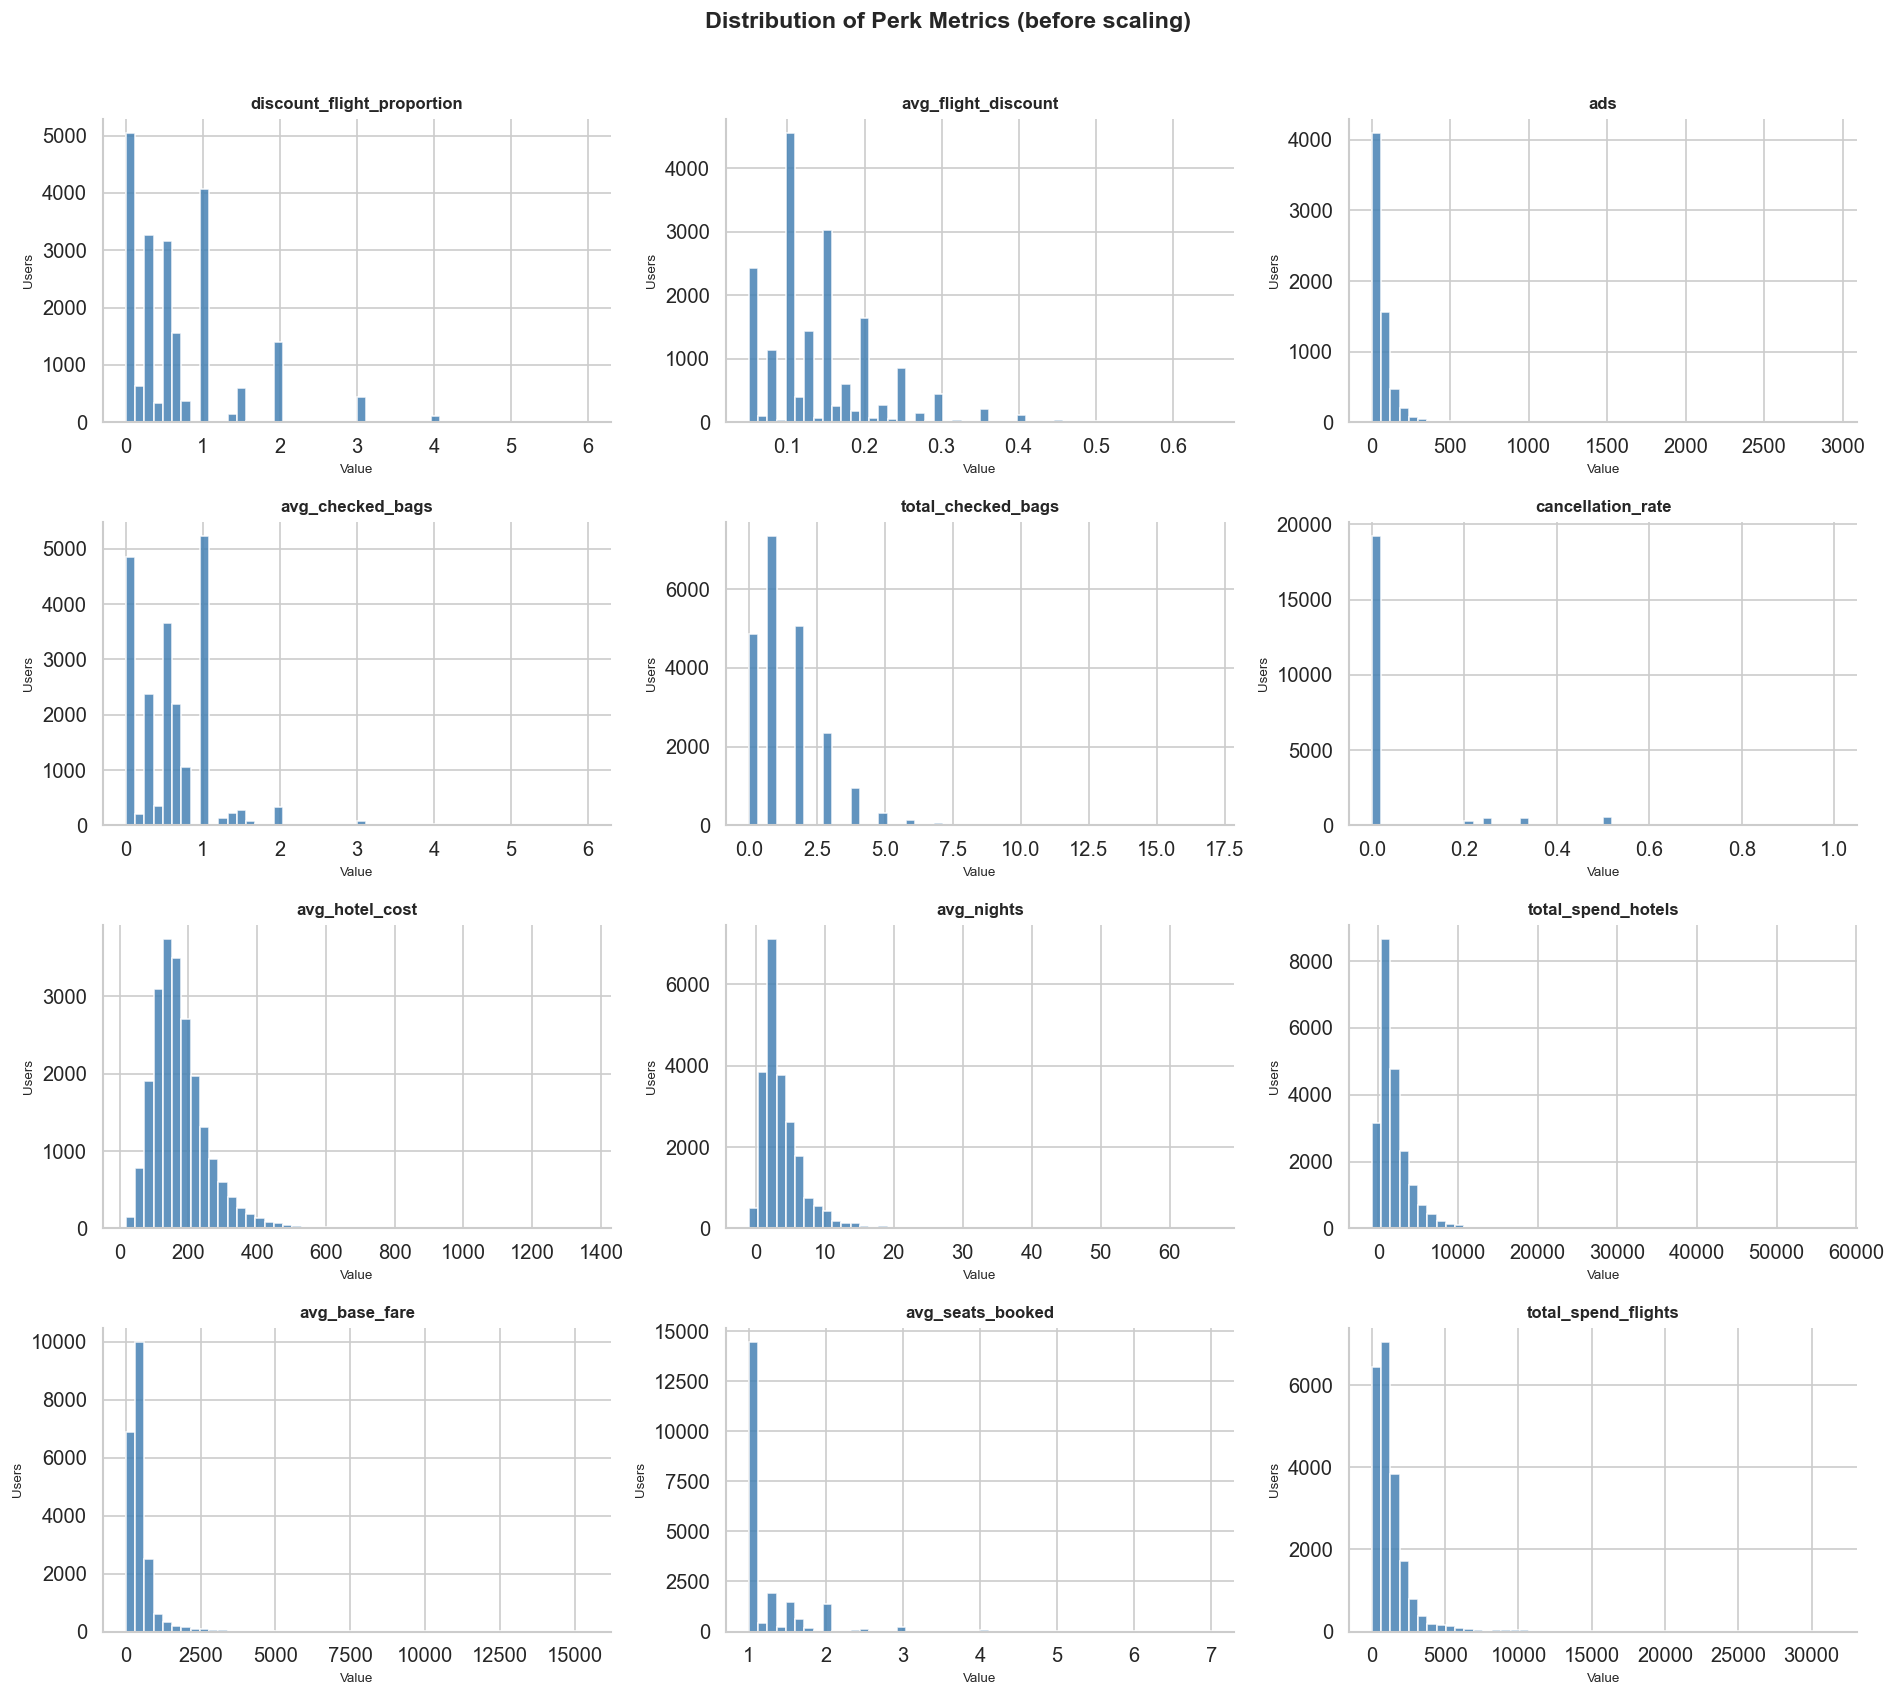

✅ Plot saved to outputs/


In [51]:
# Distribution plots for all 12 perk metrics
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(perk_metrics):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Users', fontsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Distribution of Perk Metrics (before scaling)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### 2.3 Correlation Between Perk Metrics

We check correlations between metrics to understand if any are redundant.
If two metrics are very strongly correlated, we may consider dropping one.

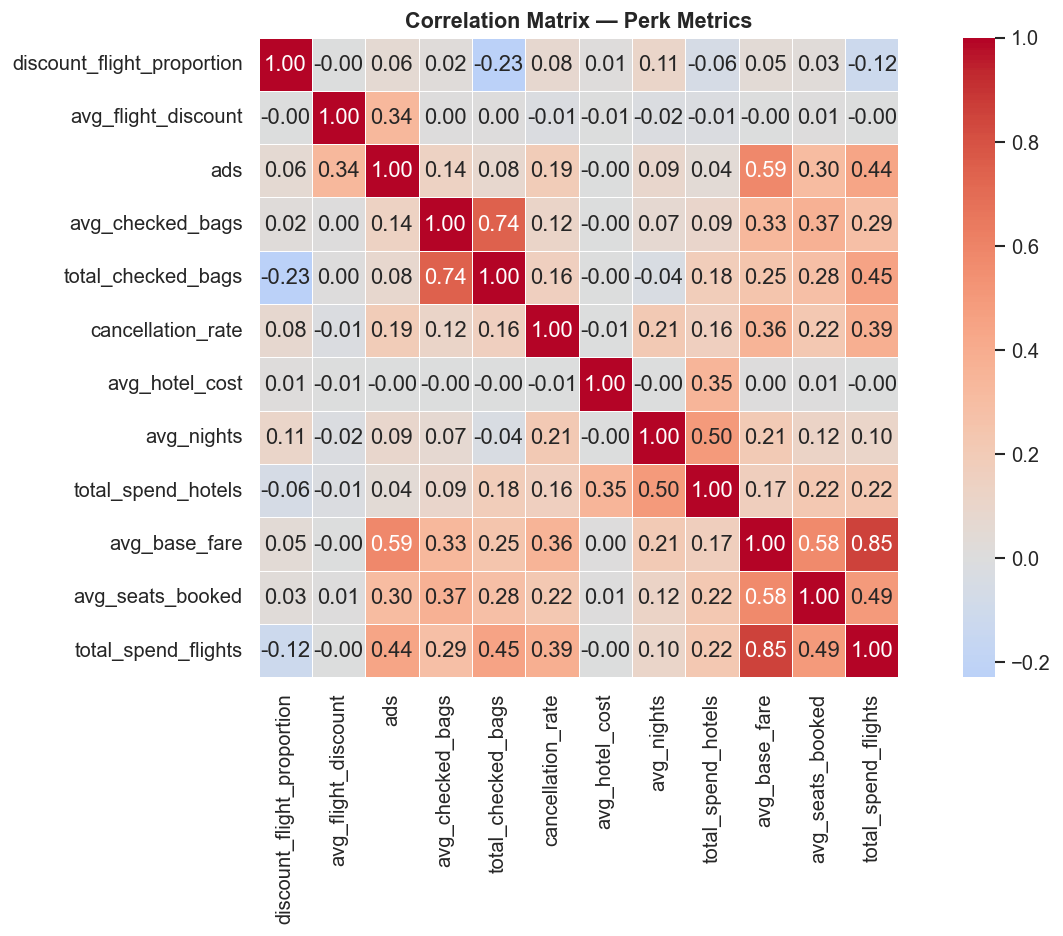

✅ Plot saved to outputs/


In [52]:
# Correlation heatmap between all perk metrics
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = df[perk_metrics].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Matrix — Perk Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### Correlation Observations

**Strong correlations (above 0.7):**
- `avg_checked_bags` & `total_checked_bags` → **0.74** — expected, both measure bag behavior
- `avg_base_fare` & `total_spend_flights` → **0.85** — expected, higher fares = higher total spend
- `avg_nights` & `total_spend_hotels` → **0.50** — moderate, longer stays = more hotel spend

**Key insight:**
Despite some correlations within the same perk group, correlations **across different perk groups
are very weak** (mostly below 0.2). This confirms that our 5 perks are measuring genuinely
different behaviors — which is exactly what we want for segmentation.

**Decision:** We keep all 12 metrics. The correlations within perk groups are expected
and acceptable — they will be combined into a single index per perk anyway.

---
## 3. Feature Engineering

This section has three steps:
1. **Fill nulls with 0** — absence of behavior = zero affinity for that perk
2. **Cap outliers at 99th percentile** — prevents extreme values from dominating the scaling
3. **MinMax scale all metrics to 0–1** — puts all metrics on the same scale so distance calculations are fair

In [53]:
# Step 1 — Fill nulls with 0
# Absence of behavior = zero affinity for that perk
df[perk_metrics] = df[perk_metrics].fillna(0)

In [54]:
# Confirm no more missing values
print('Missing values after fill:')
print(df[perk_metrics].isnull().sum())

Missing values after fill:
discount_flight_proportion    0
avg_flight_discount           0
ads                           0
avg_checked_bags              0
total_checked_bags            0
cancellation_rate             0
avg_hotel_cost                0
avg_nights                    0
total_spend_hotels            0
avg_base_fare                 0
avg_seats_booked              0
total_spend_flights           0
dtype: int64


### 3.1 Outlier Visualization — Before Capping

Box plots reveal outliers clearly. Any dots beyond the whiskers are extreme values
that could distort our scaling if not handled.

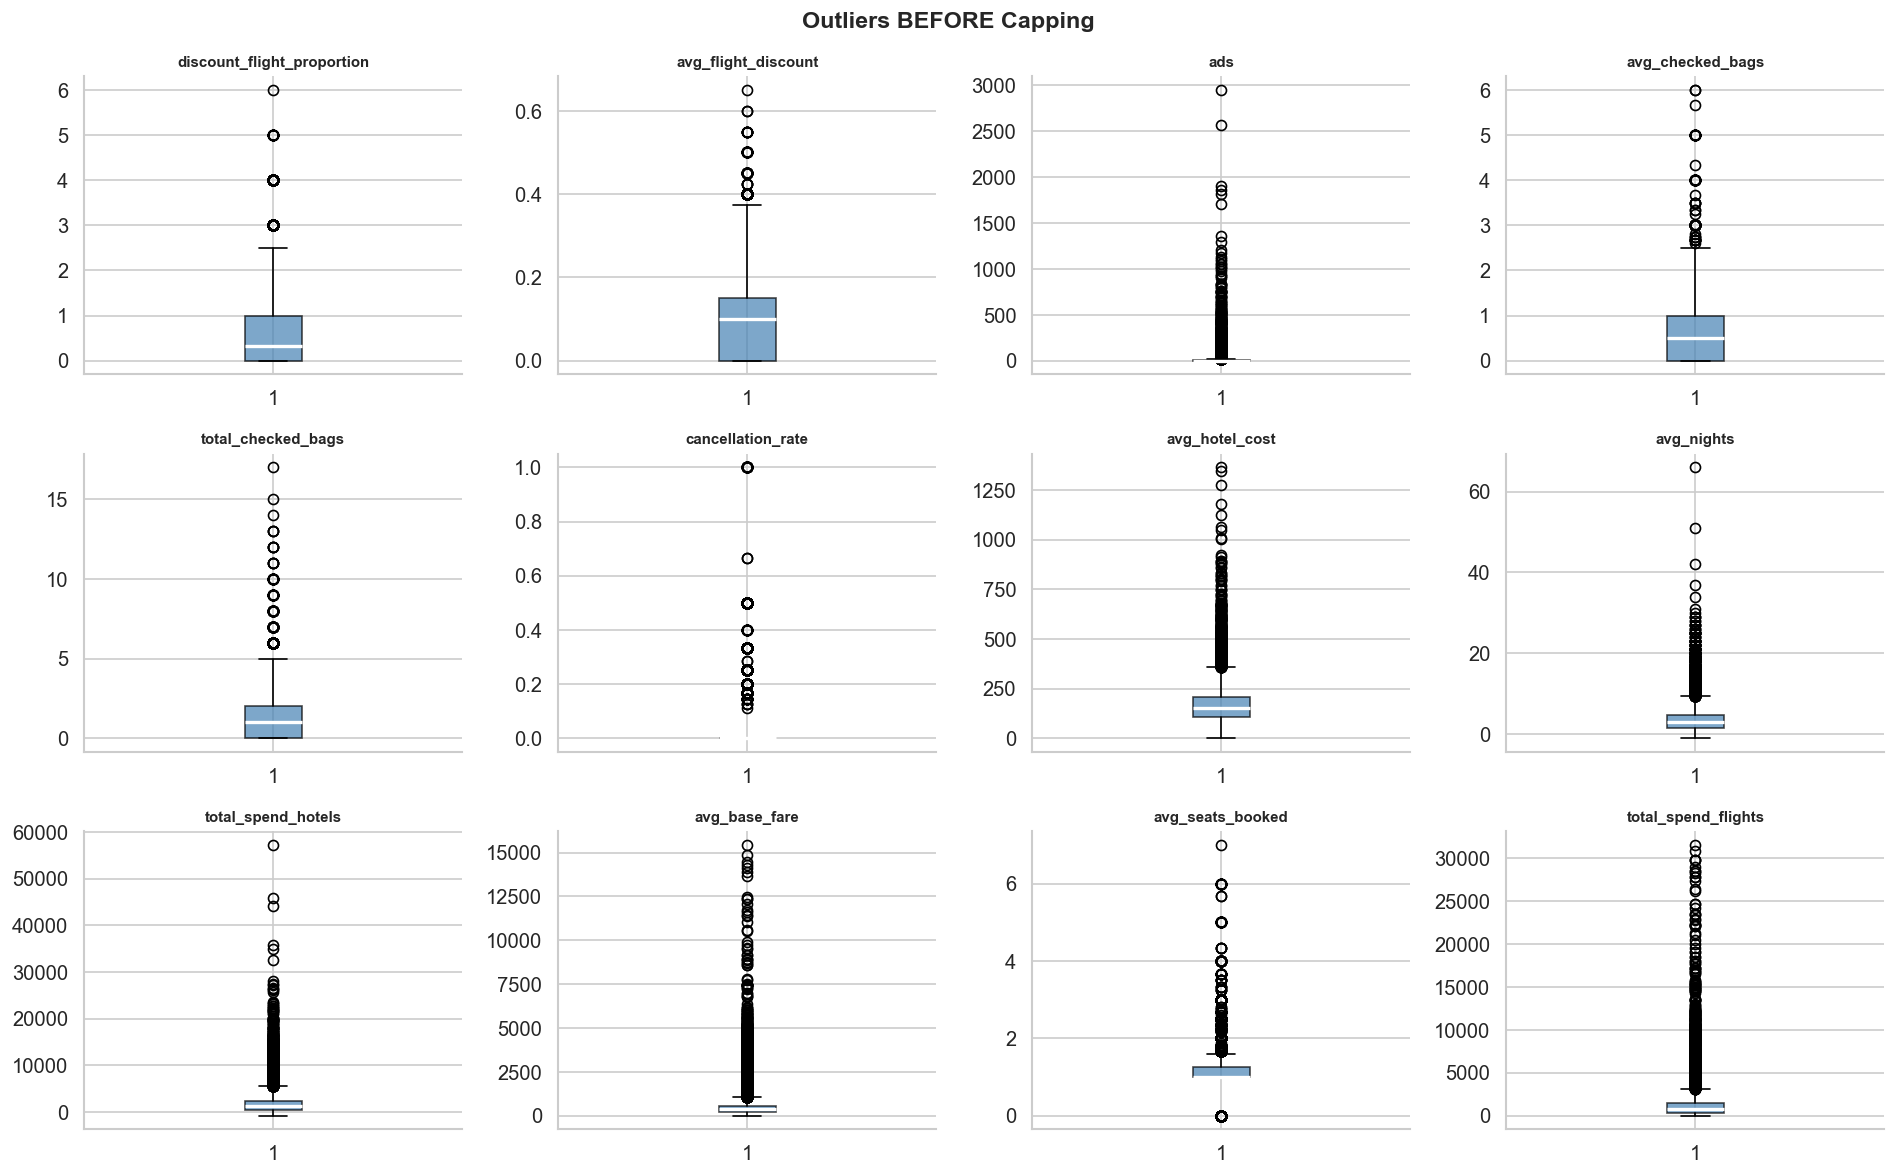

In [55]:
# Box plots BEFORE capping
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(perk_metrics):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='white', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Outliers BEFORE Capping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Cap Outliers at 99th Percentile

The box plots above clearly show extreme outliers in `ads`, `total_spend_hotels`,
`avg_base_fare` and `total_spend_flights`. We cap all metrics at the 99th percentile
and clip negative values to 0.

In [56]:
# Step 2 — Cap outliers at 99th percentile + clip negatives to 0
for col in perk_metrics:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=0, upper=cap)

In [57]:
# Confirm min and max after capping
df[perk_metrics].agg(['min', 'max']).round(3)

,discount_flight_proportion,avg_flight_discount,ads,avg_checked_bags,total_checked_bags,cancellation_rate,avg_hotel_cost,avg_nights,total_spend_hotels,avg_base_fare,avg_seats_booked,total_spend_flights
min,0.0,0.00,0.000,0.0,0.0,0.0,0.000,0.0,0.00,0.000,0.0,0.000
max,3.0,0.35,233.941,2.0,6.0,0.5,462.257,15.0,10645.93,3448.005,3.0,8645.002


### 3.3 Outlier Visualization — After Capping

Comparing to the previous box plots, the distributions are now much more compact.
The extreme outliers have been removed and the data is ready for scaling.

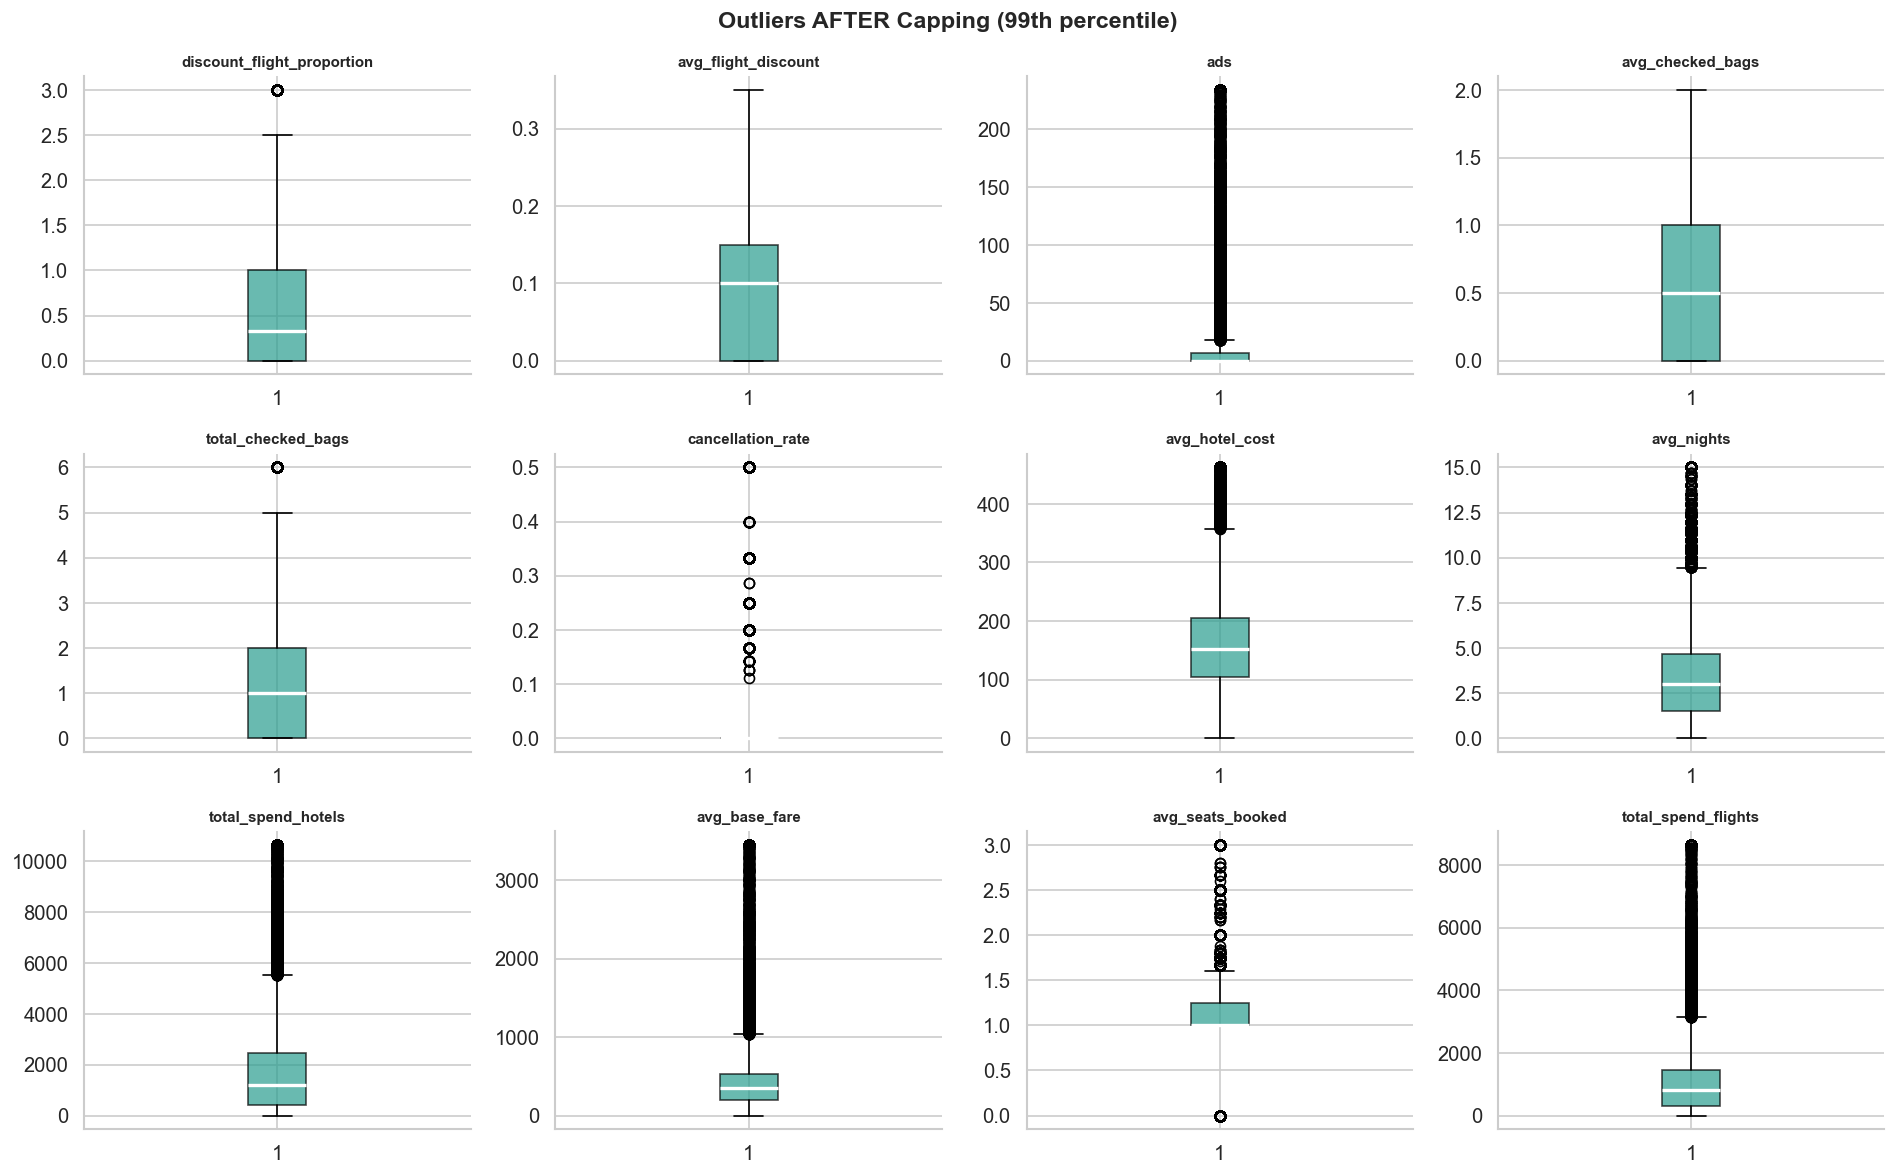

In [58]:
# Box plots AFTER capping
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(perk_metrics):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#2A9D8F', alpha=0.7),
                    medianprops=dict(color='white', linewidth=2))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

fig.suptitle('Outliers AFTER Capping (99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 MinMax Scaling

Now that outliers are handled, we scale all 12 metrics to the range **0–1**.

This is critical because our metrics are on very different scales:
- `cancellation_rate` is already 0–1
- `avg_base_fare` is in hundreds of dollars
- `total_spend_hotels` is in thousands of dollars

Without scaling, distance-based calculations would be dominated by the
largest numbers. MinMax scaling gives every metric equal weight.

In [59]:
# Step 3 — MinMax scale all perk metrics to 0–1
scaler = MinMaxScaler()

scaled_cols = ['scaled_' + col for col in perk_metrics]
df[scaled_cols] = scaler.fit_transform(df[perk_metrics])

print('✅ Scaling complete')
print(f'Original columns : {len(perk_metrics)}')
print(f'Scaled columns added : {len(scaled_cols)}')
df[scaled_cols].describe().round(3)

✅ Scaling complete
Original columns : 12
Scaled columns added : 12


,scaled_discount_flight_proportion,scaled_avg_flight_discount,scaled_ads,scaled_avg_checked_bags,scaled_total_checked_bags,scaled_cancellation_rate,scaled_avg_hotel_cost,scaled_avg_nights,scaled_total_spend_hotels,scaled_avg_base_fare,scaled_avg_seats_booked,scaled_total_spend_flights
count,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000,24724.000
mean,0.187,0.290,0.070,0.248,0.213,0.054,0.340,0.230,0.169,0.129,0.344,0.131
std,0.220,0.243,0.171,0.234,0.216,0.195,0.200,0.197,0.189,0.147,0.185,0.154
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.227,0.100,0.038,0.056,0.333,0.037
50%,0.111,0.286,0.000,0.250,0.167,0.000,0.329,0.200,0.112,0.103,0.333,0.093
75%,0.333,0.429,0.030,0.500,0.333,0.000,0.446,0.311,0.230,0.154,0.417,0.168
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


---
## 4. Perk Affinity Indexes

For each perk we combine its scaled metrics into a single **composite index score**
by taking their product.

Why product and not sum?
- The product rewards customers who score **high on all metrics** for a perk
- A customer who flies frequently but never discounts gets a low discount index
- The sum would inflate scores for customers who are strong on just one metric

| Perk | Metrics Combined |
|------|-----------------|
| 🏷️ Exclusive Discounts | discount_flight_proportion × avg_flight_discount × ads |
| 🧳 Free Checked Bag | avg_checked_bags × total_checked_bags |
| ❌ No Cancellation Fee | cancellation_rate (single metric) |
| 🍽️ Free Hotel Meal | avg_hotel_cost × avg_nights × total_spend_hotels |
| 🛫 Priority Boarding | avg_base_fare × avg_seats_booked × total_spend_flights |

In [60]:
# Build one composite index per perk (product of scaled metrics)
df['idx_discount']     = (df['scaled_discount_flight_proportion'] *
                          df['scaled_avg_flight_discount'] *
                          df['scaled_ads'])

df['idx_bag']          = (df['scaled_avg_checked_bags'] *
                          df['scaled_total_checked_bags'])

df['idx_cancellation'] =  df['scaled_cancellation_rate']

df['idx_hotel']        = (df['scaled_avg_hotel_cost'] *
                          df['scaled_avg_nights'] *
                          df['scaled_total_spend_hotels'])

df['idx_priority']     = (df['scaled_avg_base_fare'] *
                          df['scaled_avg_seats_booked'] *
                          df['scaled_total_spend_flights'])

perk_indexes = ['idx_discount', 'idx_bag', 'idx_cancellation', 'idx_hotel', 'idx_priority']

print('✅ Perk indexes created')
df[perk_indexes].describe().round(4)

✅ Perk indexes created


,idx_discount,idx_bag,idx_cancellation,idx_hotel,idx_priority
count,24724.0000,24724.0000,24724.0000,24724.0000,24724.0000
mean,0.0092,0.0925,0.0539,0.0275,0.0206
std,0.0336,0.1383,0.1946,0.0631,0.0854
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0013,0.0008
50%,0.0000,0.0417,0.0000,0.0075,0.0036
75%,0.0012,0.1111,0.0000,0.0256,0.0092
max,0.6666,1.0000,1.0000,1.0000,1.0000


### 4.1 Perk Index Distributions

We visualize the distribution of each perk index to understand
how affinity is spread across the 24,724 users.

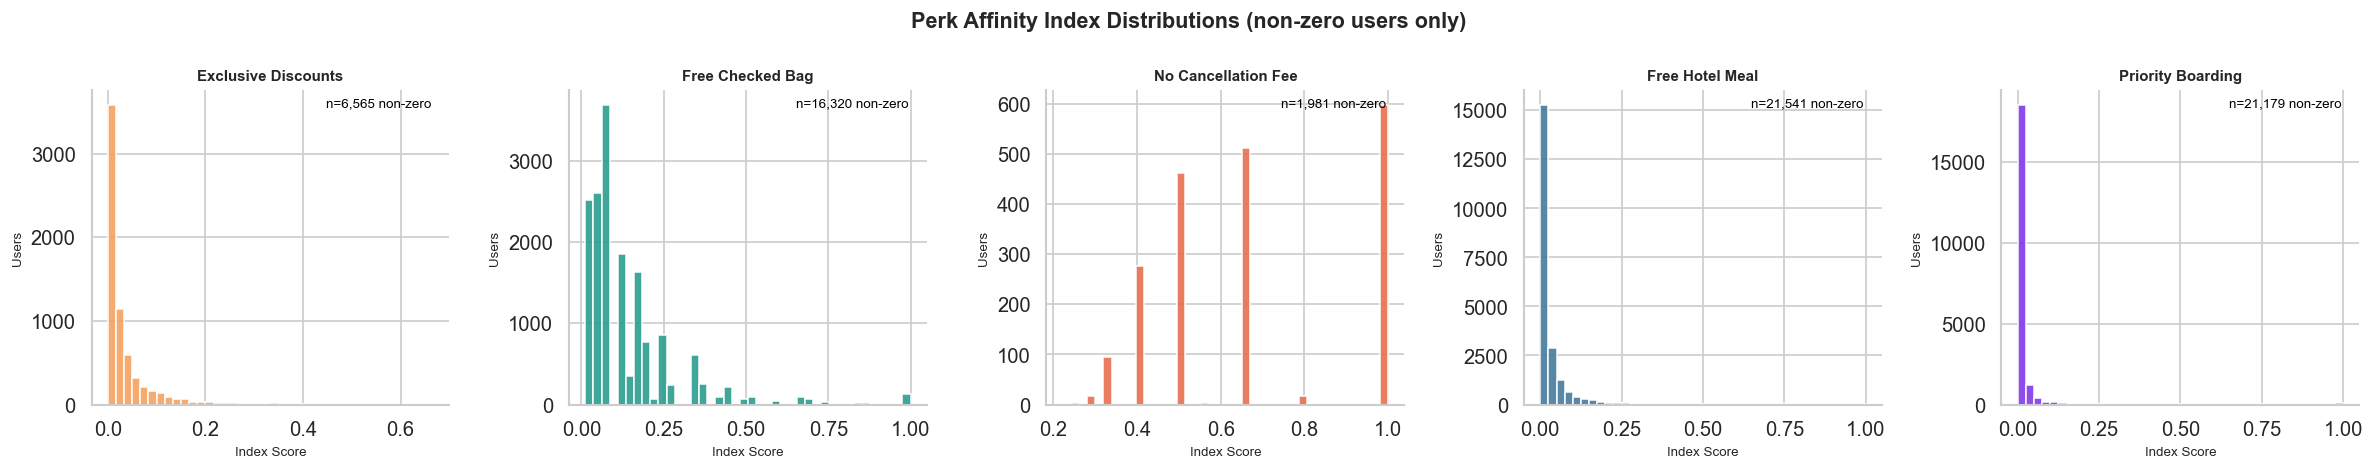

✅ Plot saved to outputs/


In [61]:
# Distribution of each perk index (non-zero users only)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

perk_labels = ['Exclusive Discounts', 'Free Checked Bag',
               'No Cancellation Fee', 'Free Hotel Meal', 'Priority Boarding']

for ax, col, label in zip(axes, perk_indexes, perk_labels):
    color = PERK_COLORS[label]
    data  = df[col][df[col] > 0]
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Index Score', fontsize=8)
    ax.set_ylabel('Users', fontsize=8)
    ax.annotate(f'n={len(data):,} non-zero', xy=(0.95, 0.95),
                xycoords='axes fraction', ha='right', fontsize=8,
                color='black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Perk Affinity Index Distributions (non-zero users only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/perk_index_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### Observations

- **Exclusive Discounts** (n=6,565): Most users cluster near 0 — only a small group
  are active discount hunters. Right-skewed as expected.

- **Free Checked Bag** (n=16,320): The most evenly spread distribution —
  bag checking behavior varies widely across users.

- **No Cancellation Fee** (n=1,981): Very few users cancel flights — only 8% of
  the cohort has any cancellation history. Discrete spikes because cancellation
  rate takes only a few possible values.

- **Free Hotel Meal** (n=21,541): Most users have some hotel activity but scores
  are concentrated near 0 — few are truly high hotel spenders.

- **Priority Boarding** (n=21,179): Similar to hotel meal — most users have
  some flight activity but very few score high on all three premium metrics.

**Key takeaway:** No single perk dominates — there is genuine behavioral
diversity in the cohort, which means segmentation will be meaningful.

---
## 5. Rule-Based Fuzzy Segmentation

Our goal is to assign each of the 24,724 customers to **exactly one perk** —
the one they have the strongest affinity for.

**How Fuzzy Segmentation works:**
1. For each perk, rank all customers by their perk index (highest score = rank 1)
2. Every customer gets a rank for each of the 5 perks
3. Assign each customer to the perk where their rank is **lowest** (i.e. highest affinity)
4. Result: every customer belongs to exactly one perk — **mutually exclusive segments**

This approach is called "fuzzy" because customers can have affinity for multiple
perks — we simply assign them to their strongest one.

In [62]:
# Step 1 — Rank all customers per perk (rank 1 = highest affinity)
df['rank_discount']     = df['idx_discount'].rank(ascending=False, method='first')
df['rank_bag']          = df['idx_bag'].rank(ascending=False, method='first')
df['rank_cancellation'] = df['idx_cancellation'].rank(ascending=False, method='first')
df['rank_hotel']        = df['idx_hotel'].rank(ascending=False, method='first')
df['rank_priority']     = df['idx_priority'].rank(ascending=False, method='first')

print('✅ Rankings created')
df[['rank_discount', 'rank_bag', 'rank_cancellation',
    'rank_hotel', 'rank_priority']].head(10)

✅ Rankings created


,rank_discount,rank_bag,rank_cancellation,rank_hotel,rank_priority
0,5376.0,13809.0,1982.0,9019.0,10798.0
1,6566.0,16321.0,1983.0,21542.0,21180.0
2,5637.0,7528.0,1984.0,12166.0,20286.0
3,6567.0,16322.0,1985.0,1745.0,21181.0
4,6568.0,16323.0,1986.0,1536.0,4689.0
5,1989.0,373.0,1591.0,4244.0,5152.0
6,6569.0,16324.0,1987.0,21543.0,21182.0
7,6570.0,16325.0,1988.0,21544.0,21183.0
8,6571.0,880.0,1.0,841.0,594.0
9,6572.0,1989.0,1989.0,16338.0,14539.0


In [63]:
# Step 2 — Assign each customer to the perk where their rank is lowest
rank_cols = ['rank_discount', 'rank_bag', 'rank_cancellation',
             'rank_hotel', 'rank_priority']

perk_map = {
    'rank_discount'     : 'Exclusive Discounts',
    'rank_bag'          : 'Free Checked Bag',
    'rank_cancellation' : 'No Cancellation Fee',
    'rank_hotel'        : 'Free Hotel Meal',
    'rank_priority'     : 'Priority Boarding'
}

# Find which rank column has the minimum value per row
df['best_rank_col'] = df[rank_cols].idxmin(axis=1)

# Map that column name to the perk name
df['assigned_perk'] = df['best_rank_col'].map(perk_map)

print('✅ Every customer assigned to one perk')
print(f'Any unassigned: {df["assigned_perk"].isnull().sum()}')
print()
print('=== SEGMENT SIZES ===')
print(df['assigned_perk'].value_counts())

✅ Every customer assigned to one perk
Any unassigned: 0

=== SEGMENT SIZES ===
assigned_perk
No Cancellation Fee    6501
Free Hotel Meal        5227
Free Checked Bag       4867
Priority Boarding      4275
Exclusive Discounts    3854
Name: count, dtype: int64


### Segmentation Results

| Perk | Customers | Share |
|------|-----------|-------|
| 🏷️ Exclusive Discounts | 3,854 | 15.6% |
| 🧳 Free Checked Bag | 4,867 | 19.7% |
| ❌ No Cancellation Fee | 6,501 | 26.3% |
| 🍽️ Free Hotel Meal | 5,227 | 21.1% |
| 🛫 Priority Boarding | 4,275 | 17.3% |

**Observations:**
- All 24,724 customers are assigned — zero unassigned
- Segments are reasonably balanced — no single perk dominates excessively
- No Cancellation Fee is the largest segment (26.3%) — suggesting many users
  have cancellation history in this cohort
- Exclusive Discounts is the smallest (15.6%) — consistent with our earlier
  finding that only 6,565 users had any discount affinity at all

### 5.1 Segment Size Visualization

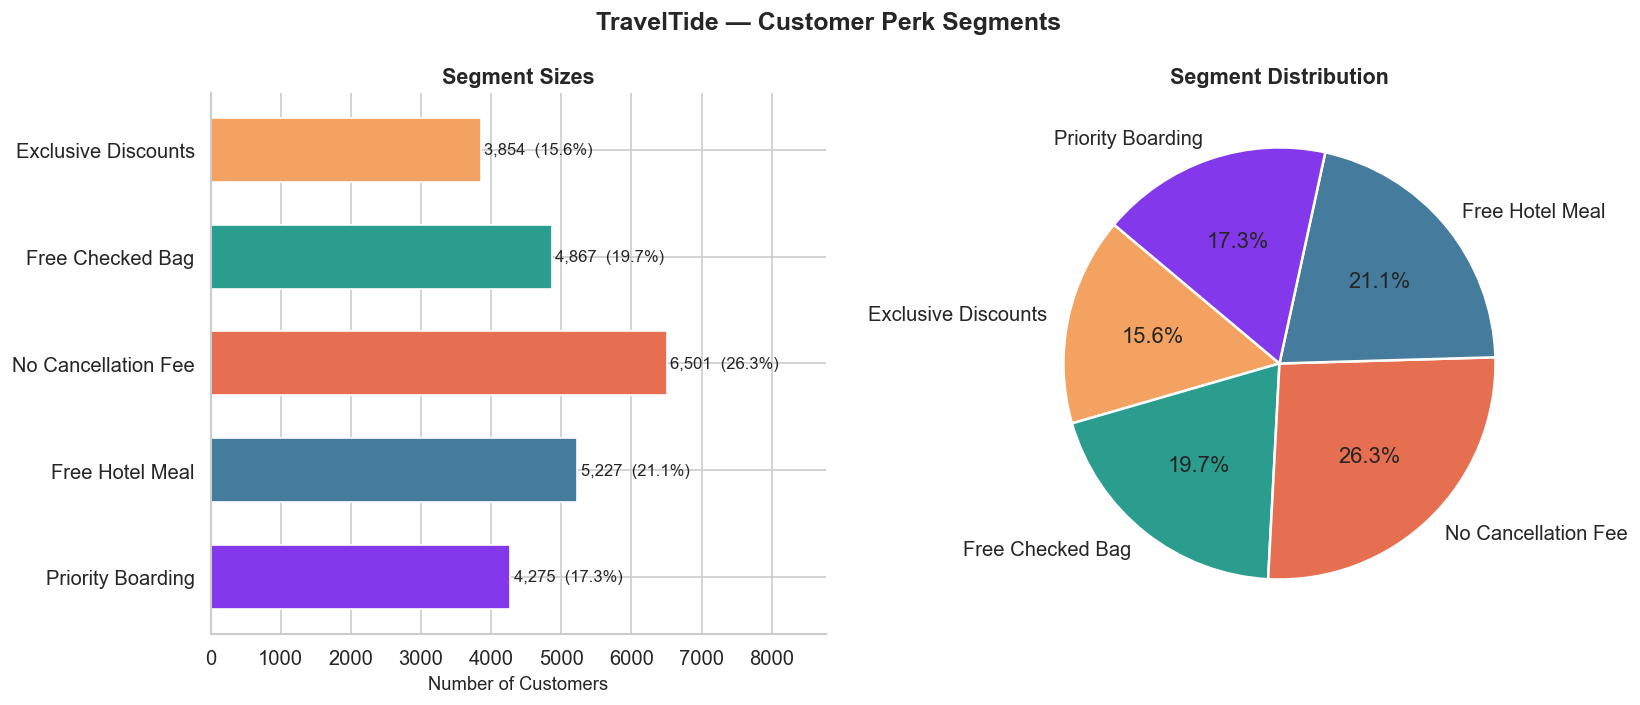

✅ Plot saved to outputs/


In [64]:
# Segment size bar chart + pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg_counts = df['assigned_perk'].value_counts().reindex(PERK_ORDER)
colors     = [PERK_COLORS[p] for p in PERK_ORDER]

# ── Bar chart ──
bars = axes[0].barh(PERK_ORDER, seg_counts.values,
                    color=colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('Number of Customers', fontsize=11)
axes[0].set_title('Segment Sizes', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
for bar, count in zip(bars, seg_counts.values):
    axes[0].text(bar.get_width() + 50,
                 bar.get_y() + bar.get_height() / 2,
                 f'{count:,}  ({count/len(df)*100:.1f}%)',
                 va='center', fontsize=10)
axes[0].set_xlim(0, max(seg_counts.values) * 1.35)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Pie chart ──
axes[1].pie(seg_counts.values, labels=PERK_ORDER, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Segment Distribution', fontsize=13, fontweight='bold')

fig.suptitle('TravelTide — Customer Perk Segments', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/segment_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### 5.2 Validation — Does Each Segment Have the Highest Affinity for Its Assigned Perk?

A good segmentation must pass this test:
> The average perk index for each segment should be **highest for its own assigned perk**
> compared to all other perks.

We visualize this as a heatmap — the **diagonal should be the darkest** in each row.

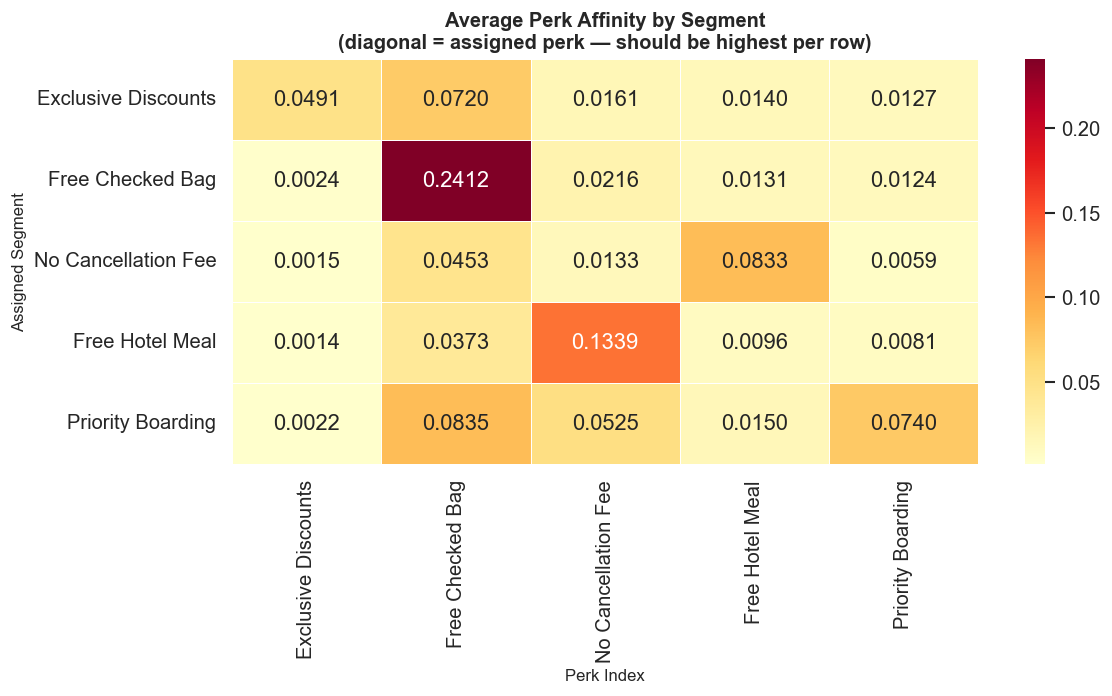

✅ Plot saved to outputs/


In [65]:
# Validation heatmap
heatmap_df = df.groupby('assigned_perk')[perk_indexes].mean()
heatmap_df.columns = PERK_ORDER
heatmap_df.index   = PERK_ORDER

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax
)
ax.set_title('Average Perk Affinity by Segment\n(diagonal = assigned perk — should be highest per row)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Perk Index', fontsize=10)
ax.set_ylabel('Assigned Segment', fontsize=10)
plt.tight_layout()
plt.savefig('./outputs/validation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### Validation Findings

Most segments pass the diagonal test — their assigned perk has the highest
affinity score in their row:
- ✅ Free Checked Bag — 0.2412 (clearly dominant)
- ✅ Free Hotel Meal — 0.1339 (clearly dominant)
- ✅ Priority Boarding — 0.0740 (clearly dominant)

Two segments show overlap:
- ⚠️ Exclusive Discounts customers also score relatively high on Free Checked Bag
- ⚠️ No Cancellation Fee customers also score relatively high on Free Hotel Meal

**Why this happens:**
The fuzzy segmentation assigns customers based on relative rank — not absolute
score. These customers ranked highest for their assigned perk across all 24,724
users, but their absolute index score is still low because discount and
cancellation behaviors are rare in the cohort overall.

**This is exactly why we run K-Means next** — to see if a distance-based
approach groups these customers differently.

---
## 6. K-Means Clustering

K-Means is an unsupervised machine learning algorithm that groups customers
based on **similarity** in behavioral space — without us telling it what the
groups mean in advance.

**How it works:**
1. We specify K=5 (one cluster per perk)
2. K-Means randomly places 5 cluster centers in the data space
3. Each customer is assigned to the nearest center
4. Centers move to the average of their assigned customers
5. Steps 3-4 repeat until centers stop moving

**Why we run it alongside rule-based segmentation:**
- Rule-based is top-down — we define what matters
- K-Means is bottom-up — the data decides the groups
- Comparing both gives us confidence in our segments

**Input:** All 12 scaled perk metrics

### 6.1 Elbow Plot — Choosing the Right K

Before running K-Means we verify that K=5 is the right number of clusters
using the **Elbow Method**. We plot inertia (sum of squared distances from
each point to its cluster center) for K=2 to K=10.

The "elbow" — where inertia stops dropping sharply — is the optimal K.

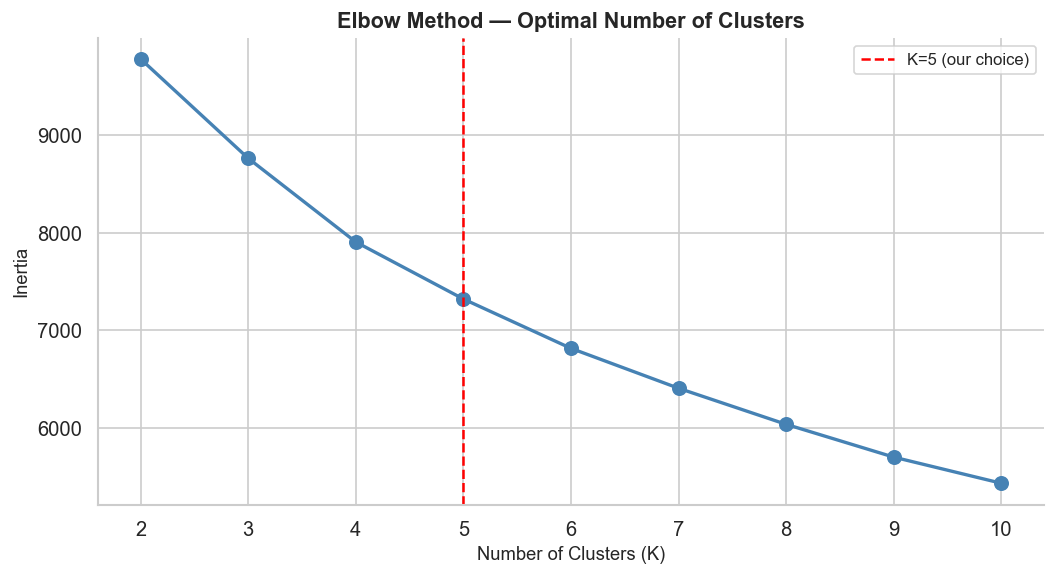

✅ Plot saved to outputs/


In [66]:
# Elbow plot — find optimal K
X = df[['scaled_' + col for col in perk_metrics]].values

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='K=5 (our choice)')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('./outputs/elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### Elbow Plot Interpretation

The curve shows a gradual decline in inertia as K increases.
There is a **subtle elbow around K=5** — after which the rate of improvement
slows down noticeably.

The elbow is not dramatic here — which is common in real-world customer
behavioral data where segments naturally overlap. This is not a problem.

We proceed with **K=5** because:
1. The elbow plot supports it
2. We have exactly 5 perks to assign
3. Business context defines the number of segments we need

In [67]:
# Run K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X)

df['kmeans_cluster'] = kmeans.labels_

print('✅ K-Means complete')
print()
print('=== CLUSTER SIZES ===')
print(df['kmeans_cluster'].value_counts().sort_index())

✅ K-Means complete

=== CLUSTER SIZES ===
kmeans_cluster
0    1256
1    6234
2    7349
3    7100
4    2785
Name: count, dtype: int64


### 6.2 K-Means Model Object

In [68]:
# Display interactive K-Means model widget
from sklearn import set_config
set_config(display='diagram')

kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### 6.3 K-Means Model Summary

In [69]:
print('=== K-MEANS MODEL SUMMARY ===')
print(f'Number of clusters (K) : {kmeans.n_clusters}')
print(f'Iterations to converge : {kmeans.n_iter_}')
print(f'Final inertia          : {kmeans.inertia_:.2f}')
print(f'Random state           : {kmeans.random_state}')
print(f'N init                 : {kmeans.n_init}')

=== K-MEANS MODEL SUMMARY ===
Number of clusters (K) : 5
Iterations to converge : 50
Final inertia          : 7321.51
Random state           : 42
N init                 : 10


In [70]:
# Profile each K-Means cluster to understand what it represents
cluster_profile = df.groupby('kmeans_cluster')[perk_indexes].mean()
cluster_profile.columns = PERK_ORDER
cluster_profile

,Exclusive Discounts,Free Checked Bag,No Cancellation Fee,Free Hotel Meal,Priority Boarding
kmeans_cluster,,,,,
0,0.022148,0.279152,0.649063,0.070203,0.251926
1,0.000927,0.015922,0.026708,0.049276,0.006676
2,0.023383,0.059137,0.019685,0.017241,0.008815
3,0.003141,0.197483,0.026189,0.021893,0.012044
4,0.000040,0.000391,0.006942,0.000967,0.000302


In [71]:
# Assign perk labels to K-Means clusters based on profile above
cluster_label_map = {
    0: 'No Cancellation Fee',
    1: 'Free Hotel Meal',
    2: 'Exclusive Discounts',
    3: 'Free Checked Bag',
    4: 'Priority Boarding'
}

df['kmeans_perk'] = df['kmeans_cluster'].map(cluster_label_map)

print('✅ Cluster labels assigned')
print()
print('=== K-MEANS SEGMENT SIZES ===')
print(df['kmeans_perk'].value_counts())

✅ Cluster labels assigned

=== K-MEANS SEGMENT SIZES ===
kmeans_perk
Exclusive Discounts    7349
Free Checked Bag       7100
Free Hotel Meal        6234
Priority Boarding      2785
No Cancellation Fee    1256
Name: count, dtype: int64


In [72]:
# Compare K-Means vs Rule-Based segment sizes
comparison = pd.DataFrame({
    'Rule-Based' : df['assigned_perk'].value_counts(),
    'K-Means'    : df['kmeans_perk'].value_counts()
}).reindex(PERK_ORDER)

comparison['Difference'] = comparison['K-Means'] - comparison['Rule-Based']

print('=== METHOD COMPARISON ===')
print(comparison)

=== METHOD COMPARISON ===
                     Rule-Based  K-Means  Difference
Exclusive Discounts        3854     7349        3495
Free Checked Bag           4867     7100        2233
No Cancellation Fee        6501     1256       -5245
Free Hotel Meal            5227     6234        1007
Priority Boarding          4275     2785       -1490


### 6.4 Cluster Visualization — PCA

Since we have 12 features we cannot visualize clusters directly.
We use PCA to reduce to 2 dimensions so we can plot and compare
both methods side by side.

In [73]:
from sklearn.decomposition import PCA

# Reduce 12 dimensions to 2 using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f'Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Variance explained by 2 components: 43.6%


### Interpreting 43.6% Variance Explained

PCA reduced 12 dimensions to 2, retaining 43.6% of the total variance.
This means our 2D plot shows the most important patterns but loses some detail.

In real-world behavioral data this is expected — customers overlap across
multiple behaviors making clean 2D separation difficult.
The plot is still valuable for visually comparing cluster shapes between methods.

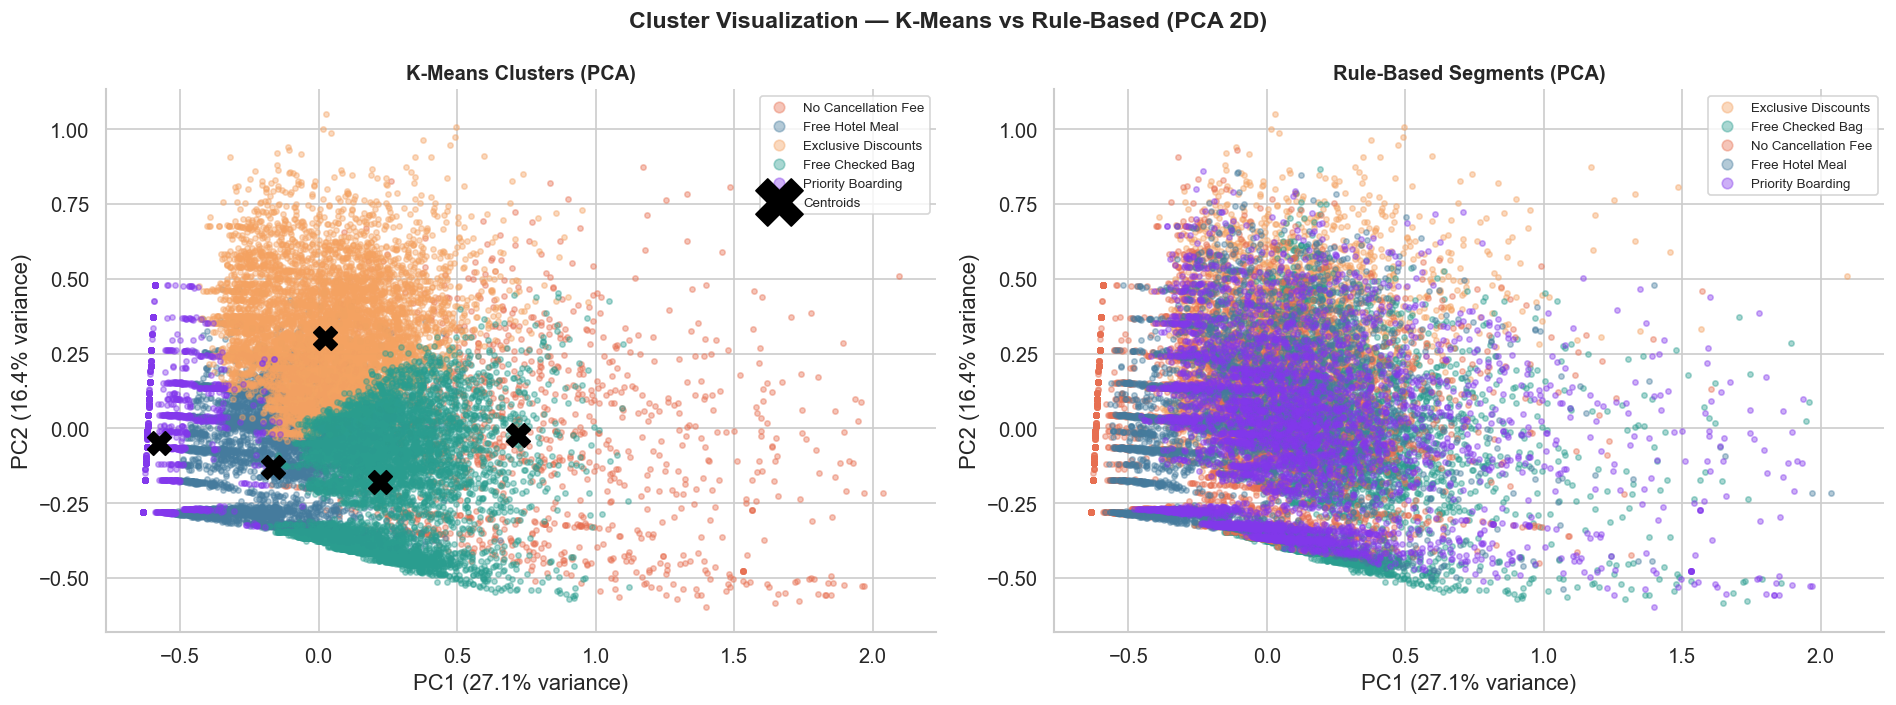

✅ Plot saved to outputs/


In [74]:
# Plot clusters in 2D PCA space — K-Means vs Rule-Based
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_colors = [PERK_COLORS[cluster_label_map[i]] for i in range(5)]

# ── K-Means clusters ──
for cluster_id in range(5):
    mask = df['kmeans_cluster'] == cluster_id
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=cluster_label_map[cluster_id],
        alpha=0.4, s=10
    )
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)
axes[0].set_title('K-Means Clusters (PCA)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(fontsize=8, markerscale=2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Rule-Based segments ──
for perk in PERK_ORDER:
    mask = df['assigned_perk'] == perk
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=PERK_COLORS[perk],
        label=perk,
        alpha=0.4, s=10
    )
axes[1].set_title('Rule-Based Segments (PCA)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(fontsize=8, markerscale=2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Cluster Visualization — K-Means vs Rule-Based (PCA 2D)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/cluster_visualization_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### PCA Cluster Visualization — Interpretation

**K-Means (left plot):**
- The 5 centroids (black X marks) are clearly separated in different regions
- K-Means forms relatively clean spatial boundaries between clusters
- Free Checked Bag (teal) and Exclusive Discounts (orange) dominate the space
- No Cancellation Fee (pink) and Priority Boarding (purple) are pushed to the edges
- This confirms K-Means over-assigns to bag and discount clusters

**Rule-Based (right plot):**
- Segments are more interleaved and overlapping
- This is expected — rule-based assigns based on relative rank not spatial distance
- The mixing of colors confirms that behavioral boundaries are not perfectly clean
- Customers genuinely share multiple behaviors simultaneously

**What this tells us:**
- K-Means finds geometrically clean clusters but misses rare behaviors
- Rule-Based captures rare but important behaviors like cancellations
- The overlap in the Rule-Based plot is not a weakness — it reflects
  real-world customer complexity

**Both plots together validate our recommendation:**
Rule-Based segmentation is more appropriate for this business problem.

### 6.5 Method Comparison — Rule-Based vs K-Means

| Perk | Rule-Based | K-Means | Difference |
|------|-----------|---------|------------|
| 🏷️ Exclusive Discounts | 3,854 | 7,349 | +3,495 |
| 🧳 Free Checked Bag | 4,867 | 7,100 | +2,233 |
| ❌ No Cancellation Fee | 6,501 | 1,256 | -5,245 |
| 🍽️ Free Hotel Meal | 5,227 | 6,234 | +1,007 |
| 🛫 Priority Boarding | 4,275 | 2,785 | -1,490 |

**Key observations:**

- **No Cancellation Fee** has the biggest disagreement — Rule-Based assigns
  6,501 customers but K-Means only 1,256. This is because cancellation behavior
  is rare and binary — K-Means struggles to form a clean cluster around it

- **Exclusive Discounts** and **Free Checked Bag** are nearly doubled by K-Means
  — K-Means is pulling in customers with moderate bag/discount behavior that
  Rule-Based assigned elsewhere

**Which method is better?**
Rule-Based is more appropriate for this business problem because:
1. The perks are **pre-defined** — we are not discovering unknown groups
2. Cancellation behavior is **rare and meaningful** — Rule-Based captures it better
3. The business needs **interpretable** segments it can act on immediately
4. K-Means struggles when clusters naturally overlap, which is the case here

K-Means is still valuable as a **validation tool** — where both methods agree,
we have high confidence in the segment assignment.

---
## 7. Segment Profiling

Now that customers are segmented, we profile each segment demographically
to understand **who** is in each group.

This is what the marketing team needs to design targeted campaigns.

In [75]:
# Demographic profile per segment
profile = df.groupby('assigned_perk').agg(
    count        = ('user_id', 'count'),
    avg_age      = ('age', 'mean'),
    pct_female   = ('gender', lambda x: (x == 'F').mean() * 100),
    pct_married  = ('married', 'mean'),
    pct_children = ('has_children', 'mean'),
    avg_sessions = ('total_sessions', 'mean'),
    avg_flights  = ('total_flights_booked', 'mean'),
    avg_hotels   = ('total_hotels_booked', 'mean'),
    avg_cancellations = ('total_cancellations', 'mean')
).reindex(PERK_ORDER).round(2)

profile

,count,avg_age,pct_female,pct_married,pct_children,avg_sessions,avg_flights,avg_hotels,avg_cancellations
assigned_perk,,,,,,,,,
Exclusive Discounts,3854,44.22,78.78,0.41,0.30,7.30,2.68,2.63,0.03
Free Checked Bag,4867,44.43,79.78,0.44,0.34,7.30,2.74,2.66,0.04
No Cancellation Fee,6501,42.15,78.83,0.40,0.31,7.30,1.54,1.59,0.19
Free Hotel Meal,5227,42.89,81.33,0.42,0.33,7.27,1.77,2.47,0.02
Priority Boarding,4275,44.17,79.65,0.45,0.32,7.29,2.75,2.54,0.08


### 7.1 Demographic Visualizations

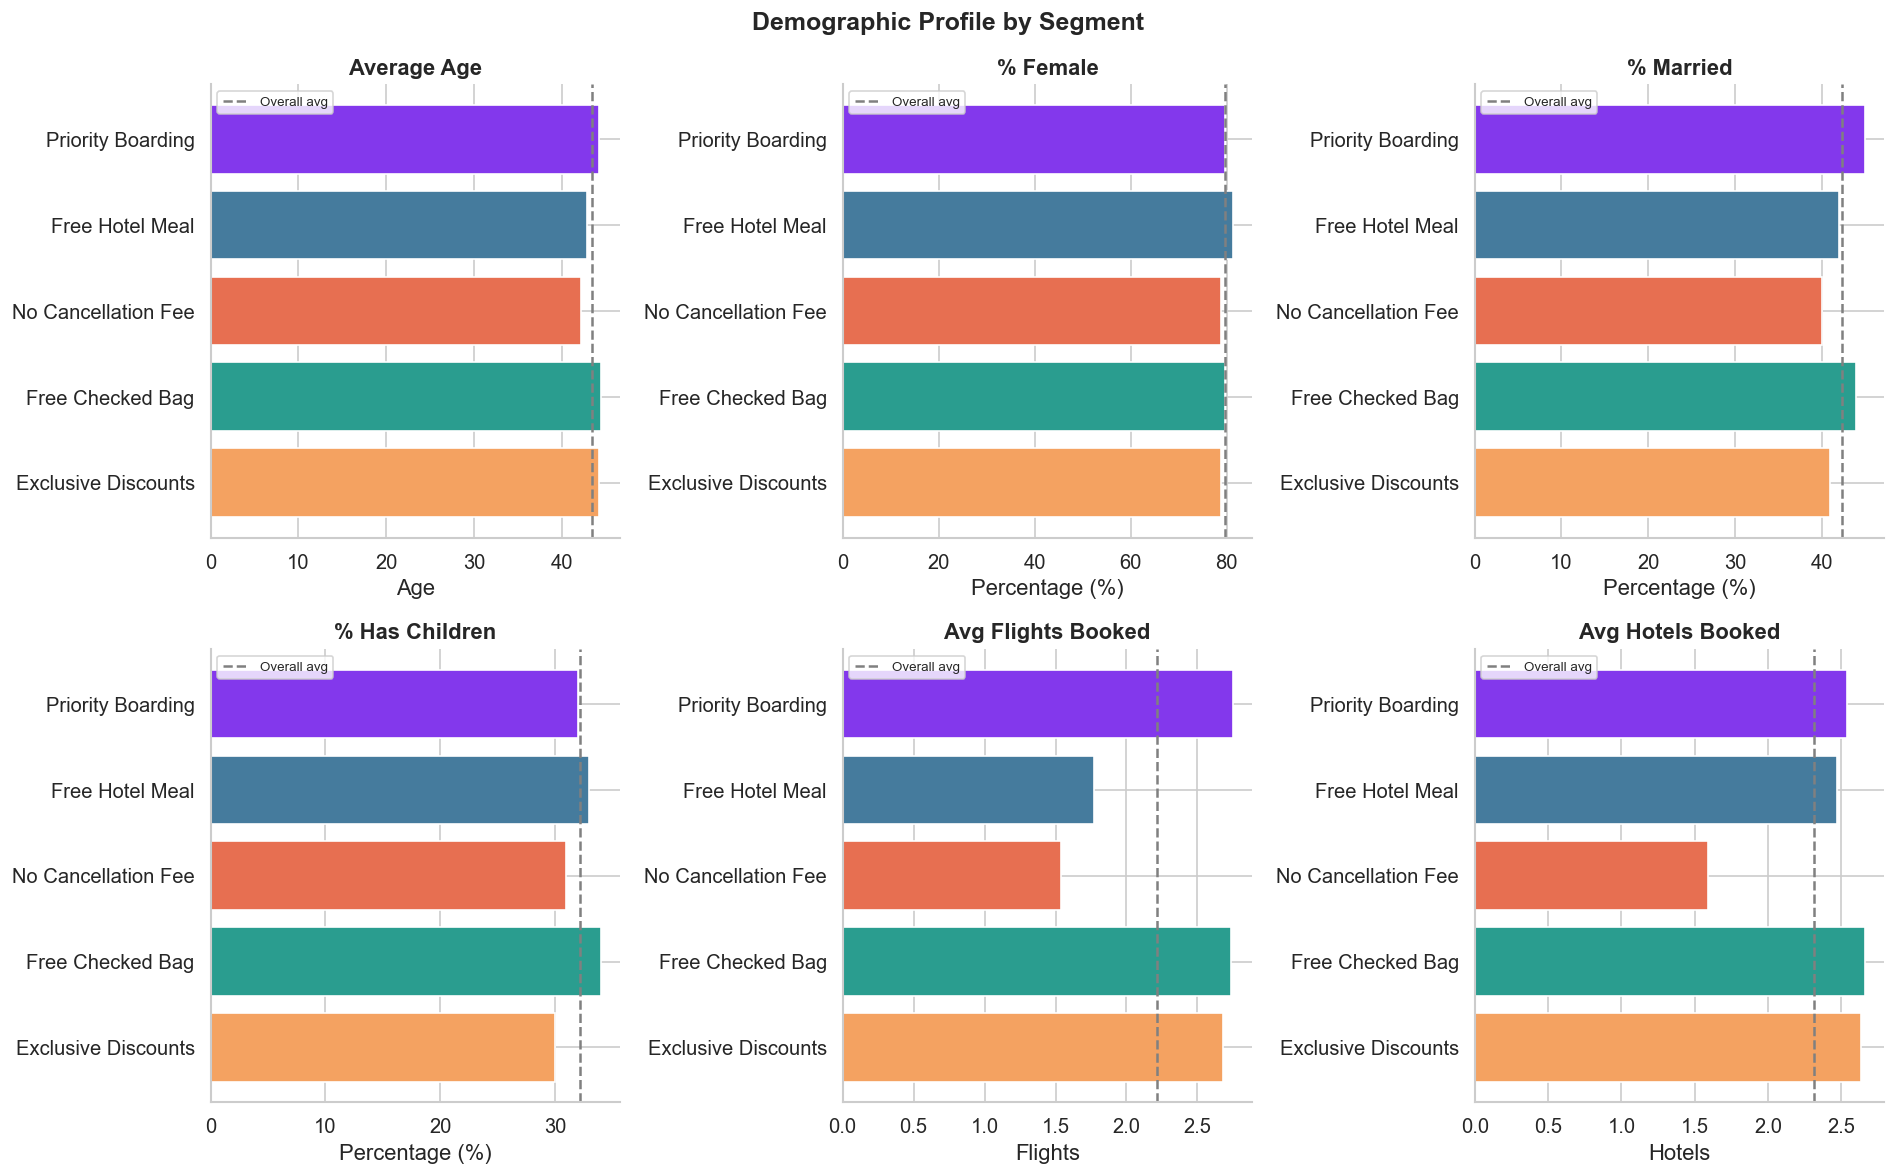

✅ Plot saved to outputs/


In [76]:
# Demographic profile visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = [PERK_COLORS[p] for p in PERK_ORDER]

# ── Average Age ──
axes[0,0].barh(PERK_ORDER, profile['avg_age'], color=colors, edgecolor='white')
axes[0,0].set_title('Average Age', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].axvline(x=df['age'].mean(), color='grey', linestyle='--', linewidth=1.5, label='Overall avg')
axes[0,0].legend(fontsize=8)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

# ── % Female ──
axes[0,1].barh(PERK_ORDER, profile['pct_female'], color=colors, edgecolor='white')
axes[0,1].set_title('% Female', fontweight='bold')
axes[0,1].set_xlabel('Percentage (%)')
axes[0,1].axvline(x=df['gender'].eq('F').mean()*100, color='grey', linestyle='--', linewidth=1.5, label='Overall avg')
axes[0,1].legend(fontsize=8)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

# ── % Married ──
axes[0,2].barh(PERK_ORDER, profile['pct_married']*100, color=colors, edgecolor='white')
axes[0,2].set_title('% Married', fontweight='bold')
axes[0,2].set_xlabel('Percentage (%)')
axes[0,2].axvline(x=df['married'].mean()*100, color='grey', linestyle='--', linewidth=1.5, label='Overall avg')
axes[0,2].legend(fontsize=8)
axes[0,2].spines['top'].set_visible(False)
axes[0,2].spines['right'].set_visible(False)

# ── % Has Children ──
axes[1,0].barh(PERK_ORDER, profile['pct_children']*100, color=colors, edgecolor='white')
axes[1,0].set_title('% Has Children', fontweight='bold')
axes[1,0].set_xlabel('Percentage (%)')
axes[1,0].axvline(x=df['has_children'].mean()*100, color='grey', linestyle='--', linewidth=1.5, label='Overall avg')
axes[1,0].legend(fontsize=8)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# ── Average Flights Booked ──
axes[1,1].barh(PERK_ORDER, profile['avg_flights'], color=colors, edgecolor='white')
axes[1,1].set_title('Avg Flights Booked', fontweight='bold')
axes[1,1].set_xlabel('Flights')
axes[1,1].axvline(x=df['total_flights_booked'].mean(), color='grey', linestyle='--', linewidth=1.5, label='Overall avg')
axes[1,1].legend(fontsize=8)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

# ── Average Hotels Booked ──
axes[1,2].barh(PERK_ORDER, profile['avg_hotels'], color=colors, edgecolor='white')
axes[1,2].set_title('Avg Hotels Booked', fontweight='bold')
axes[1,2].set_xlabel('Hotels')
axes[1,2].axvline(x=df['total_hotels_booked'].mean(), color='grey', linestyle='--', linewidth=1.5, label='Overall avg')
axes[1,2].legend(fontsize=8)
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)

fig.suptitle('Demographic Profile by Segment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to outputs/')

### Segment Profile Insights

**Age:** All segments are similar in age (42–44 years). Age alone does not
differentiate segments — behavioral data is doing the heavy lifting here.

**Gender:** The cohort is predominantly female (~79%) across all segments.
No significant gender differences between segments.

**Married:** Priority Boarding and Free Checked Bag have the highest
proportion of married customers (45%) — suggesting stable, possibly
dual-income households who travel more comfortably.

**Children:** Segments are similar (~30–34%). Free Checked Bag slightly
higher — families tend to check more bags when travelling.

**Avg Flights Booked:** 
- Priority Boarding and Free Checked Bag book the most flights (2.75)
- No Cancellation Fee books the fewest (1.54) — these customers attempt
  to book but cancel more often than they complete trips

**Avg Hotels Booked:**
- Exclusive Discounts, Free Checked Bag and Priority Boarding book
  the most hotels (~2.6)
- No Cancellation Fee books the fewest hotels (1.59) — consistent
  with their lower flight completion rate

**Overall:** Segments are demographically similar but behaviorally distinct —
which confirms that behavioral segmentation is the right approach here.
Demographics alone would not have separated these customers meaningfully.

---
## 8. Export Final Segments

We export the final segmented dataset to `outputs/` for use in
reporting, Streamlit deployment, and stakeholder presentation.

In [77]:
# Select final columns to export
final_cols = [
    'user_id', 'age', 'gender', 'married', 'has_children',
    'home_country', 'home_city',
    'total_sessions', 'total_flights_booked',
    'total_hotels_booked', 'total_cancellations',
    'discount_flight_proportion', 'avg_flight_discount', 'ads',
    'avg_checked_bags', 'cancellation_rate',
    'avg_hotel_cost', 'avg_nights', 'total_spend_hotels',
    'avg_base_fare', 'avg_seats_booked', 'total_spend_flights',
    'idx_discount', 'idx_bag', 'idx_cancellation',
    'idx_hotel', 'idx_priority',
    'assigned_perk', 'kmeans_perk'
]

df_final = df[final_cols].copy()

df_final.to_csv('./outputs/traveltide_final_segments.csv', index=False)

print('✅ Final dataset exported')
print(f'Shape  : {df_final.shape}')
print(f'Columns: {df_final.shape[1]}')
print()
print('=== FINAL SEGMENT DISTRIBUTION ===')
print(df_final['assigned_perk'].value_counts())

✅ Final dataset exported
Shape  : (24724, 29)
Columns: 29

=== FINAL SEGMENT DISTRIBUTION ===
assigned_perk
No Cancellation Fee    6501
Free Hotel Meal        5227
Free Checked Bag       4867
Priority Boarding      4275
Exclusive Discounts    3854
Name: count, dtype: int64


---
## 9. Conclusions & Recommendations

### What We Built
A complete customer segmentation pipeline that assigns each of TravelTide's
24,724 active customers to exactly one rewards program perk based on their
booking behavior.

### Final Segment Summary

| Perk | Customers | Share | Key Behavior |
|------|-----------|-------|--------------|
| 🏷️ Exclusive Discounts | 3,854 | 15.6% | Actively books discounted flights |
| 🧳 Free Checked Bag | 4,867 | 19.7% | Consistently checks bags on flights |
| ❌ No Cancellation Fee | 6,501 | 26.3% | High cancellation history |
| 🍽️ Free Hotel Meal | 5,227 | 21.1% | High hotel spend and long stays |
| 🛫 Priority Boarding | 4,275 | 17.3% | Books premium high-fare flights |

### Method Recommendation
**Rule-Based Fuzzy Segmentation** is recommended over K-Means for this
business problem because:
- Perks are pre-defined — we are assigning to known categories
- Cancellation behavior is rare but meaningful — K-Means misses it
- Results are fully interpretable and explainable to stakeholders
- K-Means confirmed our segments where both methods agreed

### Next Steps
1. Deploy segments to the rewards program platform
2. Design one targeted marketing email per segment
3. Monitor perk redemption rates per segment after launch
4. Re-run segmentation quarterly as customer behavior evolves